In [1]:
# ============================================================
# BusinessPulse AI
# Notebook 10 : Statistical Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Notebook 10 Loaded Successfully")


Notebook 10 Loaded Successfully


In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
orders = pd.read_csv("../data/processed/orders_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")

print("Datasets Loaded")

Datasets Loaded


In [3]:
analysis = (
    orders
    .merge(payments,on="order_id")
    .merge(order_items,on="order_id")
    .merge(products,on="product_id")
)

analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [4]:
analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   payment_sequential             117601 non-null  int64  
 9   payment_type                   117601 non-null  object 
 10  payment_installments           117601 non-null  int64  
 11  payment_value                  117601 non-null  float64
 12  order_item_id                 

In [5]:
analysis.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,117601,117601,117601,117601,117586,116356,115034,117601,117601.000000,117601,...,117601.000000,117601.000000,115903,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000
unique,98665,98665,7,98111,90173,81016,95663,449,NaN,4,...,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20 00:00:00,NaN,credit_card,...,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,63,63,115035,63,63,63,63,649,NaN,86769,...,NaN,NaN,11823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.093528,NaN,...,120.824783,20.045990,NaN,48.799823,784.179344,2.190441,2114.068971,30.256341,16.629689,23.068052
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.726692,NaN,...,184.479323,15.861315,NaN,9.965860,648.708817,1.713142,3788.520900,16.189688,13.457890,11.747537
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,0.850000,0.000000,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,39.900000,13.080000,NaN,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,74.900000,16.290000,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,134.900000,21.190000,NaN,57.000000,979.000000,3.000000,1800.000000,38.000000,20.000000,30.000000


In [6]:
analysis.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2567
product_category_name            1698
order_delivered_carrier_date     1245
order_approved_at                  15
customer_id                         0
order_id                            0
order_status                        0
order_estimated_delivery_date       0
payment_sequential                  0
order_purchase_timestamp            0
payment_type                        0
payment_installments                0
order_item_id                       0
payment_value                       0
seller_id                           0
shipping_limit_date                 0
price                               0
product_id                          0
freight_value                       0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
dtype: int64

In [7]:
numeric = analysis.select_dtypes(include=np.number)

corr = numeric.corr()

corr

,payment_sequential,payment_installments,payment_value,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
payment_sequential,1.000000,-0.085736,-0.063839,-0.002393,0.006989,0.023210,-0.004696,0.009658,-0.011630,0.044727,0.049751,0.025217,0.031635
payment_installments,-0.085736,1.000000,0.274131,0.073499,0.278645,0.186020,0.019988,0.037107,0.002243,0.177470,0.117067,0.121954,0.137573
payment_value,-0.063839,0.274131,1.000000,0.264328,0.739501,0.373891,0.002462,0.155731,0.011090,0.302904,0.138494,0.216924,0.148381
order_item_id,-0.002393,0.073499,0.264328,1.000000,-0.060488,-0.030568,-0.023059,-0.014489,-0.053295,-0.004613,0.004704,0.028835,-0.010154
price,0.006989,0.278645,0.739501,-0.060488,1.000000,0.415809,0.017679,0.200129,0.052528,0.338805,0.145533,0.224187,0.172576
freight_value,0.023210,0.186020,0.373891,-0.030568,0.415809,1.000000,0.022064,0.096158,0.022978,0.611866,0.310001,0.393859,0.325738
product_name_lenght,-0.004696,0.019988,0.002462,-0.023059,0.017679,0.022064,1.000000,0.089302,0.142852,0.020494,0.057236,-0.030588,0.060741
product_description_lenght,0.009658,0.037107,0.155731,-0.014489,0.200129,0.096158,0.089302,1.000000,0.119561,0.063329,0.009068,0.073736,-0.066160
product_photos_qty,-0.011630,0.002243,0.011090,-0.053295,0.052528,0.022978,0.142852,0.119561,1.000000,0.021939,0.047200,-0.031788,0.009915
product_weight_g,0.044727,0.177470,0.302904,-0.004613,0.338805,0.611866,0.020494,0.063329,0.021939,1.000000,0.463634,0.582196,0.507662


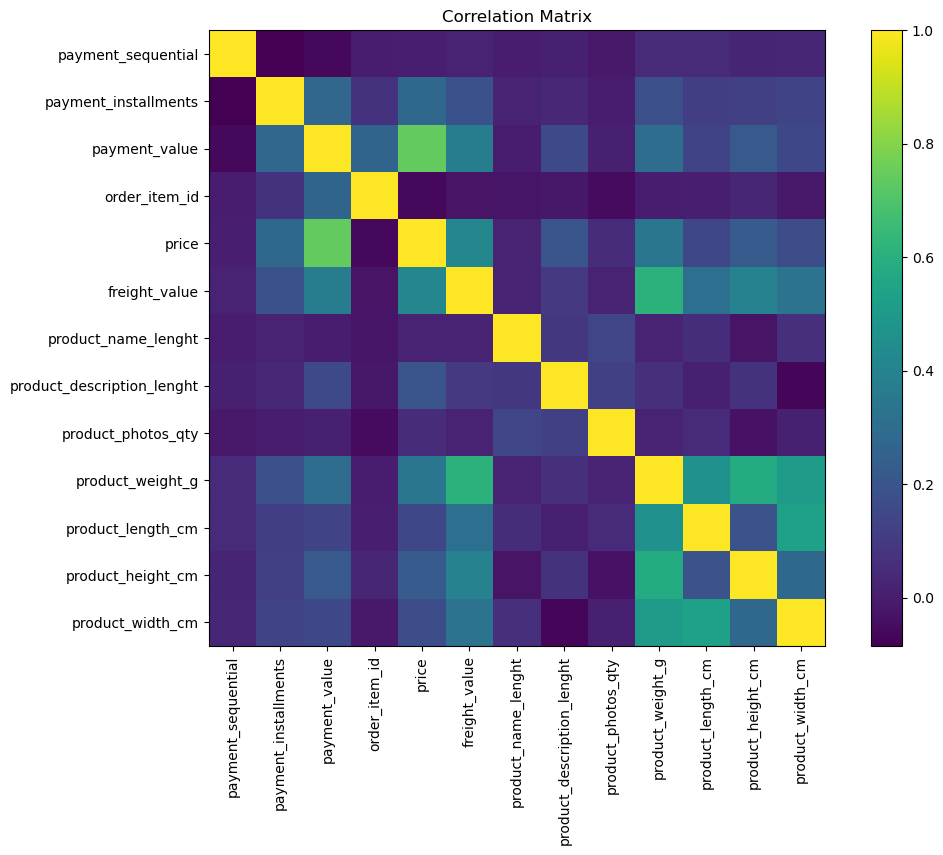

In [8]:
plt.figure(figsize=(12,8))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

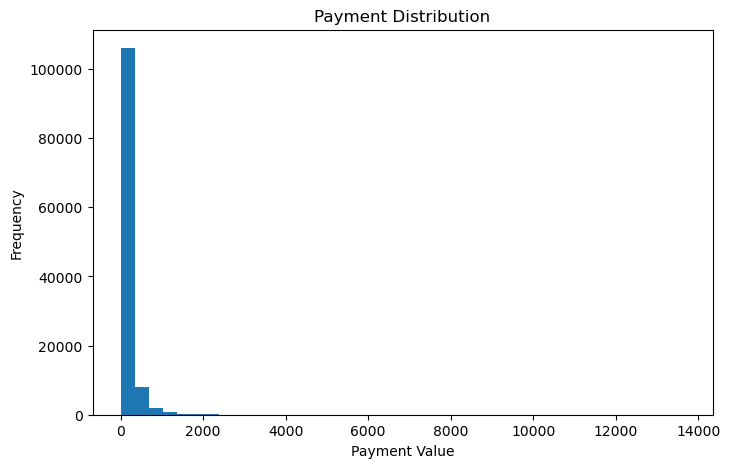

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    analysis["payment_value"],
    bins=40
)

plt.title("Payment Distribution")

plt.xlabel("Payment Value")

plt.ylabel("Frequency")

plt.show()

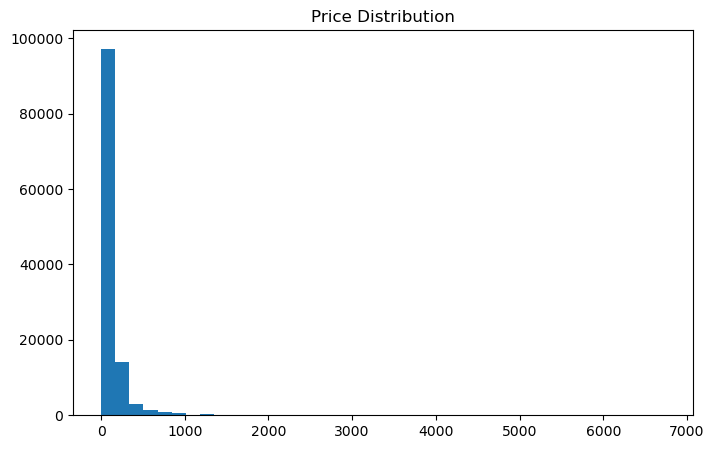

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    analysis["price"],
    bins=40
)

plt.title("Price Distribution")

plt.show()

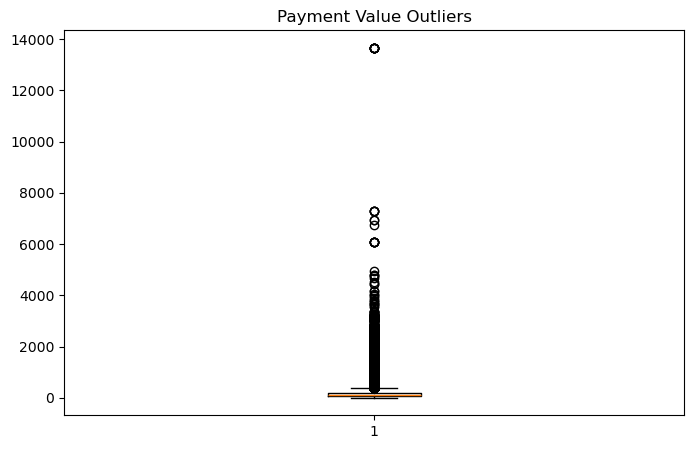

In [11]:
plt.figure(figsize=(8,5))

plt.boxplot(
    analysis["payment_value"]
)

plt.title("Payment Value Outliers")

plt.show()

In [12]:
Q1 = analysis["payment_value"].quantile(.25)

Q3 = analysis["payment_value"].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = analysis[
    (analysis["payment_value"]<lower)|
    (analysis["payment_value"]>upper)
]

print("Number of Outliers :",len(outliers))

Number of Outliers : 9495


In [13]:
analysis["order_purchase_timestamp"] = pd.to_datetime(
    analysis["order_purchase_timestamp"]
)

analysis["order_delivered_customer_date"] = pd.to_datetime(
    analysis["order_delivered_customer_date"]
)

analysis["delivery_days"] = (
    analysis["order_delivered_customer_date"]
    -
    analysis["order_purchase_timestamp"]
).dt.days

analysis["delivery_days"].describe()

count    115034.000000
mean         12.018142
std           9.459134
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

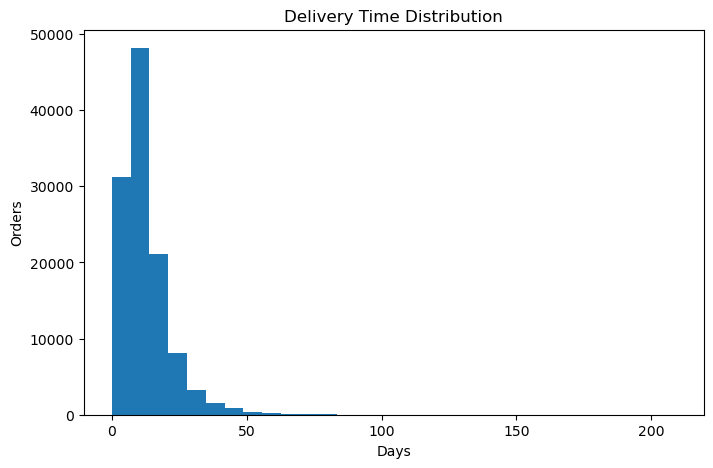

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    analysis["delivery_days"].dropna(),
    bins=30
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.show()

In [15]:
analysis.groupby(
    "payment_type"
)["payment_value"].mean().sort_values(
    ascending=False
)

payment_type
credit_card    179.661264
boleto         177.535295
debit_card     149.931319
voucher         64.691270
Name: payment_value, dtype: float64

In [16]:
analysis.groupby(
    "product_category_name"
)["payment_value"].mean().sort_values(
    ascending=False
).head(15)

product_category_name
pcs                                              1268.734318
telefonia_fixa                                    763.875498
portateis_casa_forno_e_cafe                       656.786154
agro_industria_e_comercio                         471.153214
eletrodomesticos_2                                464.789030
moveis_escritorio                                 363.794426
sinalizacao_e_seguranca                           340.736567
construcao_ferramentas_seguranca                  330.105678
instrumentos_musicais                             324.615766
eletroportateis                                   321.803680
climatizacao                                      301.889603
portateis_cozinha_e_preparadores_de_alimentos     289.043333
moveis_sala                                       257.838580
construcao_ferramentas_construcao                 253.917592
moveis_quarto                                     252.791520
Name: payment_value, dtype: float64

In [17]:
print("="*60)

print("EXECUTIVE SUMMARY")

print("="*60)

print()

print("Total Records :",len(analysis))

print()

print("Average Payment :",
      round(
          analysis["payment_value"].mean(),
          2
      ))

print()

print("Average Delivery Days :",
      round(
          analysis["delivery_days"].mean(),
          2
      ))

print()

print("Highest Payment Type")

print(
analysis.groupby("payment_type")["payment_value"].mean().idxmax()
)

EXECUTIVE SUMMARY

Total Records : 117601

Average Payment : 172.69

Average Delivery Days : 12.02

Highest Payment Type
credit_card
